# Moirai-MoE (zero-shot) — фундаментальная модель для сравнения с LSTM/трансформером

Этот ноутбук применяет **готовую предобученную** модель `Salesforce/moirai-moe-1.0-R-small` (фундаментальная модель временных рядов на разреженной смеси экспертов) к той же задаче направления нефтяных «голубых фишек», чтобы сопоставить её с обучаемыми моделями (LSTM, трансформер) из предыдущих этапов.

**Что важно понимать про эту модель:**
- Moirai — это **прогнозатор значений ряда (регрессия), а не классификатор**. Поэтому мы прогнозируем цену на 5 дней вперёд, переводим прогноз в доходность и применяем тот же порог θ, что у классификаторов, получая класс рост/боковик/падение.
- Moirai-MoE — по сути **одномерная** модель: подаём только ряд цены закрытия каждого тикера. Наши инженерные признаки (волатильность, объём, ROE) здесь **не используются** — это особенность фундаментальной модели, а не упущение.
- Это **zero-shot**: модель не обучается на наших данных. «Перенос обучения» (дообучение), который описывал преподаватель, — отдельный, более тяжёлый шаг (см. конец ноутбука).
- Moirai даёт **вероятностный** прогноз (сэмплы траекторий). Мы используем это, чтобы оценить P(доходность > θ) и P(доходность < −θ) — то есть получить «вероятности классов», аналогичные softmax классификатора, и переиспользовать те же метрики и кривую уверенности.

**Честность сравнения.** Фиксируются: TEST-период (последние 20% дат), список тикеров, горизонт 5 дней, порог θ=0.013 и торговые метрики (edge над рыночным фоном, охват). Контекст модели (длина истории) — её естественный параметр и может отличаться от окна LSTM (20 дней); это нормально, сравнивается не вход, а качество прогноза на одном и том же TEST.


## 1. Установка

In [ ]:
!pip install -q uni2ts
print('Готово. Если менялись версии — перезапустите runtime (Runtime → Restart).')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.6/170.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.8/153.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7

## 2. Импорты и конфигурация

In [ ]:
!pip install -q torchvision==0.19.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 76.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai_moe import MoiraiMoEForecast, MoiraiMoEModule

from google.colab import drive
drive.mount('/content/drive')

CONFIG = {
    'data_path'      : '/content/drive/MyDrive/full_df_sector.csv',
    'date_start'     : '2015-01-01',
    'date_end'       : '2021-12-31',
    'exclude_tickers': ['SNGS', 'SNGSP'],          # тот же пул, что у классификаторов
    'horizon'        : 5,                          # PDT — горизонт прогноза (дней)
    'class_threshold': 0.013,                      # тот же порог θ, что у LSTM/трансформера
    'test_frac'      : 0.2,                         # тот же отложенный TEST (последние 20% дат)

    # параметры Moirai-MoE
    'model_id'       : 'Salesforce/moirai-moe-1.0-R-small',
    'context_length' : 200,                        # длина истории, подаваемой модели
    'patch_size'     : 16,                          # для Moirai-MoE используется фиксированный патч 16
    'num_samples'    : 100,                         # число сэмплов вероятностного прогноза
    'batch_size'     : 64,
}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Устройство:', DEVICE)

Mounted at /content/drive
Устройство: cuda


## 3. Загрузка данных и общие функции метрик
Используем те же определения классов и те же торговые метрики, что в ноутбуках LSTM/трансформера, чтобы числа были прямо сопоставимы.

In [ ]:
df = pd.read_csv(CONFIG['data_path'])
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].between(CONFIG['date_start'], CONFIG['date_end'])]
df = df[~df['ticker'].isin(CONFIG['exclude_tickers'])]
df = df[['Date', 'ticker', 'close']].dropna().sort_values(['ticker', 'Date'])

# Граница TEST — та же логика, что у классификаторов: последние test_frac уникальных дат
all_dates = np.sort(df['Date'].unique())
cut = int(len(all_dates) * (1 - CONFIG['test_frac']))
CUTOFF = pd.Timestamp(all_dates[cut])
print('TEST начинается с', CUTOFF.date(), '| тикеры:', sorted(df['ticker'].unique()))

THR = CONFIG['class_threshold']

def make_3_classes(y, thr):
    # 0 = падение, 1 = боковик, 2 = рост
    return np.select([y < -thr, y > thr], [0, 2], default=1).astype('int64')

def trading_metrics(y_true, probs, conf=0.0):
    """Идентична функции из ноутбуков LSTM/трансформера."""
    pred = np.argmax(probs, axis=1); confident = probs.max(axis=1) >= conf
    res = {'accuracy': float(np.mean(pred == y_true)),
           'majority': float(np.bincount(y_true, minlength=3).max() / len(y_true))}
    for cls, name in [(2, 'up'), (0, 'down')]:
        sig = (pred == cls) & confident
        base = float(np.mean(y_true == cls))
        if sig.sum() > 0:
            prec = float(np.mean(y_true[sig] == cls)); cov = float(np.mean(sig))
            res[f'{name}_precision'] = prec; res[f'{name}_coverage'] = cov; res[f'{name}_edge'] = prec - base
        else:
            res[f'{name}_precision'] = np.nan; res[f'{name}_coverage'] = 0.0; res[f'{name}_edge'] = np.nan
        res[f'{name}_base'] = base
    res['n'] = int(len(y_true))
    return res

TEST начинается с 2020-08-14 | тикеры: ['BANE', 'BANEP', 'GAZP', 'LKOH', 'NVTK', 'ROSN', 'SIBN', 'TATN', 'TATNP']


## 4. Загрузка предобученной модели Moirai-MoE

In [ ]:
PDT = CONFIG['horizon']
model = MoiraiMoEForecast(
    module=MoiraiMoEModule.from_pretrained(CONFIG['model_id']),
    prediction_length=PDT,
    context_length=CONFIG['context_length'],
    patch_size=CONFIG['patch_size'],
    num_samples=CONFIG['num_samples'],
    target_dim=1,                 # одномерный ряд (только цена)
    feat_dynamic_real_dim=0,      # ковариаты не подаём (особенность MoE-версии)
    past_feat_dynamic_real_dim=0,
)
predictor = model.create_predictor(batch_size=CONFIG['batch_size'])
print('Модель загружена:', CONFIG['model_id'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/469M [00:00<?, ?B/s]

Модель загружена: Salesforce/moirai-moe-1.0-R-small


## 5. Скользящий zero-shot прогноз по TEST

Для каждого тикера на каждом дне TEST-периода модель по предыдущей истории прогнозирует цену на 5 дней вперёд (`distance=1` — окна на каждый день, как у классификаторов). Из вероятностных сэмплов получаем:
- точечный прогноз 5-дневной доходности (медиана) → предсказанный класс по θ;
- P(доходность > θ) и P(доходность < −θ) → «вероятности классов» рост/падение.

Это даёт массив `(n, 3)`, полностью совместимый с `trading_metrics`.

In [ ]:
y_true_all, probs_all, ticker_all = [], [], []

for tk, g in df.groupby('ticker'):
    g = g.sort_values('Date').reset_index(drop=True)
    n = len(g)
    # сколько точек этого тикера попадает в TEST-период
    test_len = int((g['Date'] >= CUTOFF).sum())
    if test_len <= PDT:
        print(f'{tk}: мало точек в TEST, пропуск'); continue

    # Moirai игнорирует реальный календарь — задаём синтетический дневной индекс, чтобы GluonTS был доволен
    s = pd.Series(g['close'].values,
                  index=pd.period_range('2000-01-01', periods=n, freq='D'), name=tk)
    ds = PandasDataset({tk: s})

    # последние test_len точек — тестовая зона; окна на каждый день
    _, test_template = split(ds, offset=-test_len)
    n_windows = test_len - PDT + 1
    test_data = test_template.generate_instances(prediction_length=PDT, windows=n_windows, distance=1)

    forecasts = list(predictor.predict(test_data.input))
    for inp, label, fc in zip(test_data.input, test_data.label, forecasts):
        last_close = float(np.asarray(inp['target'])[-1])
        actual_close_h = float(np.asarray(label['target'])[PDT - 1])     # факт через 5 дней
        samples_h = np.asarray(fc.samples)[:, PDT - 1]                   # сэмплы цены на горизонте 5
        if last_close <= 0:
            continue
        pred_ret   = np.median(samples_h) / last_close - 1
        actual_ret = actual_close_h / last_close - 1
        sample_rets = samples_h / last_close - 1
        p_up   = float(np.mean(sample_rets > THR))
        p_down = float(np.mean(sample_rets < -THR))
        p_flat = max(0.0, 1.0 - p_up - p_down)
        # нормируем на всякий случай
        z = p_up + p_down + p_flat
        probs_all.append([p_down / z, p_flat / z, p_up / z])
        y_true_all.append(int(make_3_classes(np.array([actual_ret]), THR)[0]))
        ticker_all.append(tk)
    print(f'{tk}: окон {len(forecasts)}')

y_true = np.array(y_true_all)
probs  = np.array(probs_all)
ticker_arr = np.array(ticker_all)
print('\nВсего прогнозов на TEST:', len(y_true))

BANE: окон 349
BANEP: окон 349
GAZP: окон 349
LKOH: окон 349
NVTK: окон 349
ROSN: окон 349
SIBN: окон 349
TATN: окон 349
TATNP: окон 349

Всего прогнозов на TEST: 3141


## 6. Результаты на TEST (сравнивать с таблицами LSTM/трансформера)

In [ ]:
base = trading_metrics(y_true, probs, conf=0.0)
print('=== Moirai-MoE zero-shot, TEST (все сигналы) ===')
for kk in ['accuracy', 'majority', 'up_precision', 'up_base', 'up_edge', 'up_coverage',
           'down_precision', 'down_edge', 'n']:
    v = base[kk]
    print(f'  {kk:14s}: {v:.3f}' if isinstance(v, float) else f'  {kk:14s}: {v}')

=== Moirai-MoE zero-shot, TEST (все сигналы) ===
  accuracy      : 0.356
  majority      : 0.350
  up_precision  : 0.347
  up_base       : 0.327
  up_edge       : 0.020
  up_coverage   : 0.435
  down_precision: 0.350
  down_edge     : -0.000
  n             : 3141


## 7. Кривая «точность ↔ охват» по уверенности
Здесь «уверенность» — это P(рост) из вероятностного прогноза Moirai. Прямой аналог кривой уверенности классификатора.

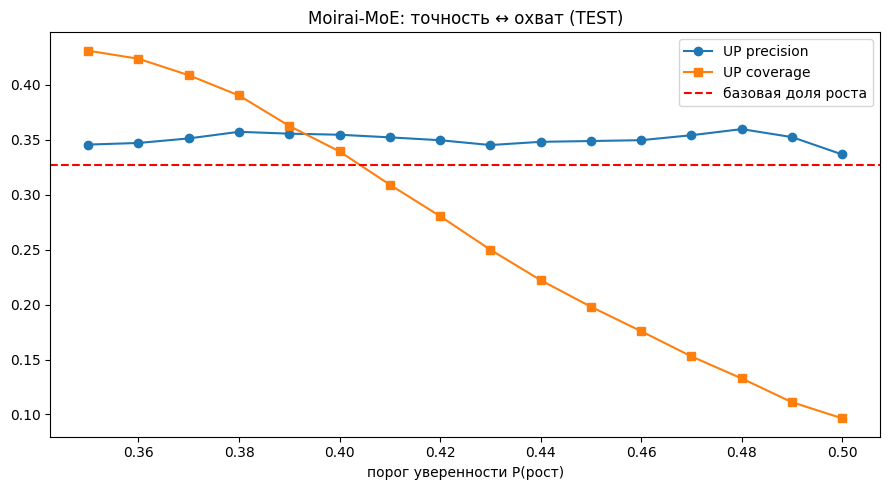

 conf  up_precision  up_coverage  up_edge
 0.35         0.346        0.431    0.019
 0.36         0.347        0.424    0.020
 0.37         0.351        0.409    0.025
 0.38         0.357        0.390    0.031
 0.39         0.356        0.363    0.029
 0.40         0.355        0.339    0.028
 0.41         0.352        0.309    0.026
 0.42         0.350        0.280    0.023
 0.43         0.345        0.250    0.019
 0.44         0.348        0.222    0.021
 0.45         0.349        0.198    0.022
 0.46         0.350        0.176    0.023
 0.47         0.354        0.153    0.028
 0.48         0.360        0.133    0.033
 0.49         0.352        0.111    0.026
 0.50         0.337        0.096    0.010


In [ ]:
confs = np.round(np.arange(0.35, 0.50, 0.01), 2)
rows = [dict(conf=c, **{k: trading_metrics(y_true, probs, c)[k]
            for k in ['up_precision', 'up_coverage', 'up_edge']}) for c in confs]
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['conf'], sweep['up_precision'], 'o-', label='UP precision')
ax.plot(sweep['conf'], sweep['up_coverage'], 's-', label='UP coverage')
ax.axhline(base['up_base'], ls='--', c='red', label='базовая доля роста')
ax.set_xlabel('порог уверенности P(рост)'); ax.set_title('Moirai-MoE: точность ↔ охват (TEST)')
ax.legend(); plt.tight_layout(); plt.show()
print(sweep.round(3).to_string(index=False))

## 8. Разбивка по тикерам и матрица ошибок

Ticker  Accuracy  UP_precision  UP_base  UP_coverage   N
  GAZP     0.387         0.436    0.436        0.605 349
  SIBN     0.361         0.415    0.395        0.504 349
  LKOH     0.378         0.394    0.352        0.487 349
  ROSN     0.344         0.384    0.410        0.628 349
  NVTK     0.341         0.332    0.350        0.596 349
  TATN     0.350         0.287    0.295        0.410 349
 TATNP     0.327         0.237    0.304        0.398 349
 BANEP     0.335         0.190    0.206        0.166 349
  BANE     0.381         0.073    0.192        0.117 349


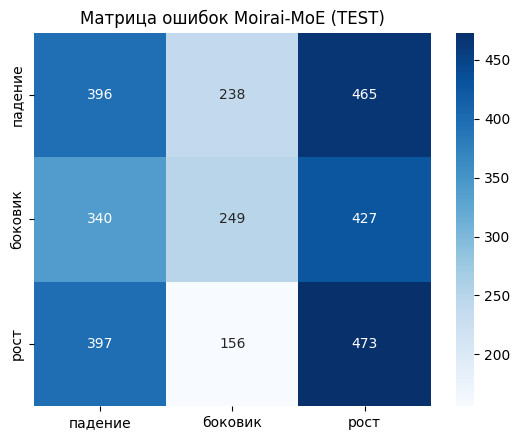

In [ ]:
pred = np.argmax(probs, axis=1)
rows = []
for tk in np.unique(ticker_arr):
    m = ticker_arr == tk; yt = y_true[m]; pr = pred[m]; up = pr == 2
    rows.append({'Ticker': tk, 'Accuracy': np.mean(pr == yt),
                 'UP_precision': (np.mean(yt[up] == 2) if up.sum() else np.nan),
                 'UP_base': np.mean(yt == 2), 'UP_coverage': np.mean(up), 'N': int(m.sum())})
print(pd.DataFrame(rows).sort_values('UP_precision', ascending=False)
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

cm = pd.crosstab(pd.Series(y_true, name='Факт'), pd.Series(pred, name='Прогноз'))
cm = cm.reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
cm.index = ['падение', 'боковик', 'рост']; cm.columns = ['падение', 'боковик', 'рост']
plt.figure(figsize=(5.5, 4.5)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок Moirai-MoE (TEST)'); plt.tight_layout(); plt.show()